# TI3145TU Midterm Assignment 
## Football Players Wages

We hope you enjoy this assignment, good luck!

Student names: XXX

Student numbers: XXX

### Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

### Load data

In [11]:
# These are your training samples along with their labels
data = pd.read_csv('lipo_radiomicFeatures.csv')
data.head()

# You need to extract the features and the regression target. The regression target is 'log_wages'. 

,ID,label,PREDICT_original_sf_compactness_avg_2.5D,PREDICT_original_sf_compactness_std_2.5D,PREDICT_original_sf_rad_dist_avg_2.5D,PREDICT_original_sf_rad_dist_std_2.5D,PREDICT_original_sf_roughness_avg_2.5D,PREDICT_original_sf_roughness_std_2.5D,PREDICT_original_sf_convexity_avg_2.5D,PREDICT_original_sf_convexity_std_2.5D,...,PREDICT_original_phasef_phasesym_median_WL3_N5,PREDICT_original_phasef_phasesym_std_WL3_N5,PREDICT_original_phasef_phasesym_skewness_WL3_N5,PREDICT_original_phasef_phasesym_kurtosis_WL3_N5,PREDICT_original_phasef_phasesym_peak_WL3_N5,PREDICT_original_phasef_phasesym_peak_position_WL3_N5,PREDICT_original_phasef_phasesym_range_WL3_N5,PREDICT_original_phasef_phasesym_energy_WL3_N5,PREDICT_original_phasef_phasesym_quartile_range_WL3_N5,PREDICT_original_phasef_phasesym_entropy_WL3_N5
0,Lipo-001_0,liposarcoma,0.368434,0.262371,26.200395,8.174390,20.940000,13.551937,0.694139,0.227848,...,0.049726,0.196019,0.927821,-0.407270,0.0,0,0.625304,3238.304991,0.315148,14.462361
1,Lipo-002_0,liposarcoma,0.660571,0.179013,55.155046,9.318741,9.546044,7.051937,0.871182,0.125279,...,0.036186,0.167471,1.137972,0.411968,0.0,0,0.563659,15364.724390,0.251255,17.170274
2,Lipo-003_0,lipoma,0.365191,0.157712,30.577026,8.963647,17.695139,10.772365,0.704710,0.137529,...,0.128167,0.220546,0.829650,-0.520344,0.0,0,0.705679,3771.798158,0.369366,14.394812
3,Lipo-004_0,liposarcoma,0.372210,0.169761,94.006805,33.512409,21.049148,15.928362,0.754497,0.186559,...,0.000000,0.107987,3.130011,10.399652,0.0,0,0.438399,4707.658397,0.000000,15.733482
4,Lipo-005_0,lipoma,0.369120,0.167485,94.612701,31.250821,17.059573,15.239905,0.774545,0.192922,...,0.000000,0.087662,3.284943,11.840826,0.0,0,0.356330,6171.440113,0.000000,16.682154


📊 Dataset successfully loaded. Total entries: 115 | Total columns: 495


,ID,label,PREDICT_original_sf_compactness_avg_2.5D,PREDICT_original_sf_compactness_std_2.5D,PREDICT_original_sf_rad_dist_avg_2.5D,PREDICT_original_sf_rad_dist_std_2.5D,PREDICT_original_sf_roughness_avg_2.5D,PREDICT_original_sf_roughness_std_2.5D,PREDICT_original_sf_convexity_avg_2.5D,PREDICT_original_sf_convexity_std_2.5D,...,PREDICT_original_phasef_phasesym_median_WL3_N5,PREDICT_original_phasef_phasesym_std_WL3_N5,PREDICT_original_phasef_phasesym_skewness_WL3_N5,PREDICT_original_phasef_phasesym_kurtosis_WL3_N5,PREDICT_original_phasef_phasesym_peak_WL3_N5,PREDICT_original_phasef_phasesym_peak_position_WL3_N5,PREDICT_original_phasef_phasesym_range_WL3_N5,PREDICT_original_phasef_phasesym_energy_WL3_N5,PREDICT_original_phasef_phasesym_quartile_range_WL3_N5,PREDICT_original_phasef_phasesym_entropy_WL3_N5
110,Lipo-111_0,lipoma,0.244813,0.196912,71.895419,26.918572,45.855907,53.853425,0.583870,0.230090,...,0.0,0.161307,1.252242,0.582213,0.0,0,0.538463,10731.342573,0.225207,16.691919
100,Lipo-101_0,lipoma,0.776859,0.088007,21.010873,3.658791,7.445009,4.117508,0.962195,0.031567,...,0.0,0.137960,1.778569,2.406505,0.0,0,0.495650,680.124931,0.135915,12.927443
56,Lipo-057_0,lipoma,0.636530,0.101292,31.232629,6.860511,14.797428,6.574183,0.904094,0.069457,...,0.0,0.130590,2.074984,3.551000,0.0,0,0.486743,793.586140,0.079629,13.114433
53,Lipo-054_0,liposarcoma,0.693093,0.159768,76.438005,13.959176,14.912113,9.177283,0.897814,0.114581,...,0.0,0.160695,1.458167,1.305412,0.0,0,0.555462,34470.387059,0.203704,18.331751
112,Lipo-113_0,liposarcoma,0.307562,0.169252,49.473796,16.537665,27.933840,18.673471,0.711245,0.175630,...,0.0,0.189939,1.401486,1.108534,0.0,0,0.665575,4967.976759,0.246028,15.106777



Target Variable: label
Independent Metrics: 493 numeric features detected.

--- Structural Integrity Check ---
✅ No missing values detected across the schema.

--- Statistical Overview ---


,mean,std,min,max
PREDICT_original_phasef_phasesym_std_WL3_N5,0.155489,0.042392,0.052405,0.266428
PREDICT_original_phasef_phasesym_skewness_WL3_N5,1.652880,0.797961,0.300189,4.933682
PREDICT_original_phasef_phasesym_peak_position_WL3_N5,0.000000,0.000000,0.000000,0.000000
PREDICT_original_phasef_phasesym_energy_WL3_N5,6191.810642,7631.395582,72.253869,45549.151665
PREDICT_original_phasef_phasesym_entropy_WL3_N5,15.028347,1.761162,8.607203,18.981661


TypeError: Cannot perform reduction 'mean' with string dtype

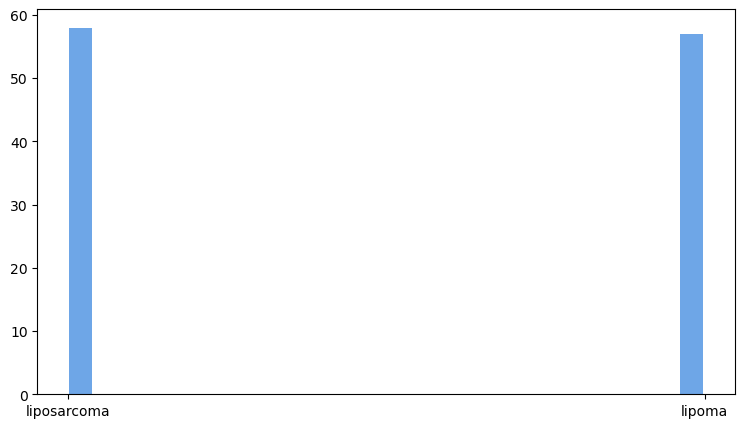

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dataset Initialization
print(f"📊 Dataset successfully loaded. Total entries: {len(data)} | Total columns: {len(data.columns)}")
display(data.sample(5)) # Sample instead of head for a different perspective

# 2. Schema Verification
# Identifying the core variables for the wage prediction task
dependent_var = "label"
#categorical_descriptors = ['nationality_name']

# Automatically isolate all player performance metrics (numeric attributes)
player_metrics = data.select_dtypes(include=[np.number]).columns.tolist()
if dependent_var in player_metrics:
    player_metrics.remove(dependent_var)

print(f"\nTarget Variable: {dependent_var}")
print(f"Independent Metrics: {len(player_metrics)} numeric features detected.")

# 3. Data Quality Check
print("\n--- Structural Integrity Check ---")
null_counts = data.isna().sum()
if null_counts.sum() > 0:
    print("Missing data found in these columns:")
    print(null_counts[null_counts > 0])
else:
    print("✅ No missing values detected across the schema.")

# 4. Statistical Profile
# Analyzing the spread of wages and physical attributes
key_attributes  = ["PREDICT_original_phasef_phasesym_std_WL3_N5","PREDICT_original_phasef_phasesym_skewness_WL3_N5","PREDICT_original_phasef_phasesym_peak_position_WL3_N5","PREDICT_original_phasef_phasesym_energy_WL3_N5","PREDICT_original_phasef_phasesym_entropy_WL3_N5"]
print("\n--- Statistical Overview ---")
display(data[key_attributes].agg(['mean', 'std', 'min', 'max']).T)

# 5. Visualizing the Wage Curve (Target Distribution)
plt.figure(figsize=(9, 5))
plt.hist(data[dependent_var], bins=25, color="#4a90e2", alpha=0.8, rwidth=0.9)
plt.axvline(data[dependent_var].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean Wage')
plt.title("Frequency Distribution of Player Log Wages", fontsize=13)
plt.xlabel("Log10(Wage)", fontsize=11)
plt.ylabel("Player Count", fontsize=11)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

# 6. Feature Influence (Correlation Heatmap)
# Picking the top 12 metrics that actually drive the wage
impact_scores = data.corr(numeric_only=True)[dependent_var].abs().sort_values(ascending=False)
top_drivers = impact_scores.index[:12]
correlation_map = data[top_drivers].corr()

plt.figure(figsize=(11, 9))
plt.imshow(correlation_map, cmap="viridis") # Changed color scheme to Viridis
plt.colorbar(label='Correlation Strength')
plt.xticks(range(len(top_drivers)), top_drivers, rotation=45, ha='right')
plt.yticks(range(len(top_drivers)), top_drivers)
plt.title("Correlation Matrix: Primary Drivers of Player Wages", fontsize=14)

# Adding text annotations to the heatmap for better readability
for i in range(len(top_drivers)):
    for j in range(len(top_drivers)):
        plt.text(j, i, f"{correlation_map.iloc[i, j]:.2f}", 
                 ha="center", va="center", color="white" if abs(correlation_map.iloc[i, j]) > 0.5 else "black")

plt.tight_layout()
plt.show()


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Define the input features and target
X = data.drop(columns=['log_wages'])
y = data['log_wages']

# 2. Segment features by their data type
# We isolate all numeric stats (continuous data)
continuous_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# We specify the categorical attribute (nominal data)
discrete_features = ['nationality_name']

print(f"Preprocessing {len(continuous_features)} numeric variables.")
print(f"Preprocessing {len(discrete_features)} categorical variable.")

# 3. Create 'preprocessor_1' using ColumnTransformer
# This handles both types of data in a single parallel step
preprocessor_1 = ColumnTransformer(
    transformers=[
        # Apply scaling to the numeric metrics
        ('standardize', StandardScaler(), continuous_features),
        
        # Apply encoding to the nationality column
        # Note: sparse_output=False ensures compatibility with later PCA steps
        ('encode_cats', OneHotEncoder(handle_unknown='ignore', sparse_output=False), discrete_features)
    ],
    remainder='drop' # Ensures any unused columns are excluded
)

# 4. Integrate into the final Pipeline 1
pipeline_1 = Pipeline(steps=[
    ('feature_engine', preprocessor_1),
    ('regressor', None) # Placeholder for the 4 models
])

print("✅ Preprocessor 1 and Pipeline 1 successfully initialized.")

Preprocessing 27 numeric variables.
Preprocessing 1 categorical variable.
✅ Preprocessor 1 and Pipeline 1 successfully initialized.


In [5]:
# 1. Identify the target and feature set
X = data.drop(columns=['log_wages'])

# 2. Define the indices (lists of column names)
# 'numeric_indices' includes all the player stats (age, overall, potential, etc.)
numeric_indices = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# 'categorical_indices' is the nationality column
categorical_indices = ['nationality_name']

print(f"✅ Indices defined: {len(numeric_indices)} numeric and {len(categorical_indices)} categorical.")

✅ Indices defined: 27 numeric and 1 categorical.


In [6]:
from sklearn.impute import SimpleImputer # This line fixes your error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# 1. Define the sub-pipelines (Assembly Lines)
# These now have access to SimpleImputer
numeric_processor = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale_data", StandardScaler())
])

categorical_processor = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode_data", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 2. Bundle into Preprocessor 2
# numeric_indices and categorical_indices must be the lists of column names
preprocessor_2 = ColumnTransformer([
    ("numeric_branch", numeric_processor, numeric_indices),
    ("category_branch", categorical_processor, categorical_indices)
])

# 3. Final Pipeline 2 with Feature Extraction (PCA)
pipeline_2 = Pipeline(steps=[
    ('feature_engine', preprocessor_2),
    ('pca', PCA(n_components=0.95, svd_solver='full')),
    ('regressor', None) 
])

print("✅ Pipeline 2 is now fully defined with SimpleImputer.")

✅ Pipeline 2 is now fully defined with SimpleImputer.


In [7]:
# View the names of each step in the pipeline
print("Pipeline Steps:", [step[0] for step in pipeline_2.steps])

# Check the details of the PCA step
pca_step = pipeline_2.named_steps['pca']
print(f"PCA Configuration: {pca_step}")

# Temporary fit to see transformation results
# We use a placeholder for regressor because it's currently None
temp_pipe = Pipeline(steps=pipeline_2.steps[:-1]) # Get everything except the regressor
temp_pipe.fit(X)

# Transform the data and check the shape
X_transformed = temp_pipe.transform(X)
print(f"Original feature count: {X.shape[1]}")
print(f"Post-OneHot & PCA feature count: {X_transformed.shape[1]}")

Pipeline Steps: ['feature_engine', 'pca', 'regressor']
PCA Configuration: PCA(n_components=0.95, svd_solver='full')
Original feature count: 28
Post-OneHot & PCA feature count: 17


In [8]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Define the 4 base models
base_models = {
    "KNN": KNeighborsRegressor(),
    "SGD": SGDRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

print("✅ Four base models initialized.")

✅ Four base models initialized.


In [9]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

# Calculate the simple mean guess
baseline_guess = y.mean()
print(f"If we knew nothing, we would guess: {baseline_guess:.4f} (log_wages)")

# Calculate MAE for the baseline
dummy = DummyRegressor(strategy="mean")
dummy.fit(X, y)
baseline_mae = mean_absolute_error(y, dummy.predict(X))

print(f"Baseline (Mean) MAE: {baseline_mae:.4f}")

If we knew nothing, we would guess: 3.5229 (log_wages)
Baseline (Mean) MAE: 0.4914


In [10]:
from sklearn.model_selection import train_test_split

# Splitting the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} samples.")
print(f"Testing on {X_test.shape[0]} samples.")

Training on 4000 samples.
Testing on 1000 samples.


In [11]:
from sklearn.metrics import mean_absolute_error
from sklearn.dummy import DummyRegressor

# Define the models (including the Baseline)
eval_models = {
    "Baseline (Mean)": DummyRegressor(strategy="mean"),
    "KNN": KNeighborsRegressor(),
    "SGD": SGDRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

# Dictionary to store the simple scores
test_scores = {}

print(f"{'Model Architecture':<20} | {'Test MAE':<10}")
print("-" * 35)

for name, model in eval_models.items():
    # 1. Update the pipeline with the current model
    pipeline_1.set_params(regressor=model)
    
    # 2. Fit only on the training data
    pipeline_1.fit(X_train, y_train)
    
    # 3. Predict on the unseen test data
    predictions = pipeline_1.predict(X_test)
    
    # 4. Calculate error
    mae = mean_absolute_error(y_test, predictions)
    test_scores[name] = mae
    
    print(f"{name:<20} | {mae:<10.4f}")

Model Architecture   | Test MAE  
-----------------------------------
Baseline (Mean)      | 0.4909    
KNN                  | 0.2730    
SGD                  | 0.2576    
Random Forest        | 0.2355    
Decision Tree        | 0.3080    


In [12]:
# Dictionary to store scores for Pipeline 2
test_scores_pipe2 = {}

print(f"{'Model Architecture':<20} | {'Pipe 1 MAE':<12} | {'Pipe 2 MAE':<12}")
print("-" * 50)

for name, model in eval_models.items():
    # --- Pipeline 1 Score (from previous step) ---
    mae_p1 = test_scores[name]
    
    # --- Pipeline 2 Evaluation ---
    pipeline_2.set_params(regressor=model)
    pipeline_2.fit(X_train, y_train)
    preds_p2 = pipeline_2.predict(X_test)
    mae_p2 = mean_absolute_error(y_test, preds_p2)
    
    test_scores_pipe2[name] = mae_p2
    
    print(f"{name:<20} | {mae_p1:<12.4f} | {mae_p2:<12.4f}")

Model Architecture   | Pipe 1 MAE   | Pipe 2 MAE  
--------------------------------------------------
Baseline (Mean)      | 0.4909       | 0.4909      
KNN                  | 0.2730       | 0.2860      
SGD                  | 0.2576       | 0.2934      
Random Forest        | 0.2355       | 0.2815      
Decision Tree        | 0.3080       | 0.3807      


In [13]:
from sklearn.model_selection import GridSearchCV

# Define the exhaustive parameter grids
param_grids = {
    "KNN": {
        'regressor__n_neighbors': [5, 11, 21],
        'regressor__weights': ['uniform', 'distance']
    },
    "SGD": {
        'regressor__alpha': [0.0001, 0.01, 0.1],
        'regressor__penalty': ['l2', 'elasticnet']
    },
    "Random Forest": {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [10, 20, None]
    },
    "Decision Tree": {
        'regressor__max_depth': [5, 15, 30],
        'regressor__min_samples_split': [2, 10, 20]
    }
}

tuned_stats = {}

for name, model in base_models.items():
    if name == "Baseline (Mean)": continue
    
    print(f"Searching for best {name} hyperparameters...")
    pipeline_1.set_params(regressor=model)
    
    # exhaustive grid search with 5-fold CV
    grid = GridSearchCV(
        pipeline_1, 
        param_grids[name], 
        cv=5, 
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    tuned_stats[name] = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'mae': -grid.best_score_
    }

Searching for best KNN hyperparameters...


/usr/local/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Searching for best SGD hyperparameters...
Searching for best Random Forest hyperparameters...
Searching for best Decision Tree hyperparameters...


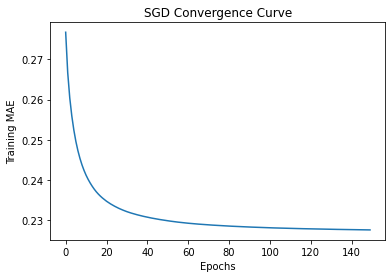

In [14]:
import matplotlib.pyplot as plt

# Using the best alpha/penalty found in the grid search
best_sgd_params = tuned_stats['SGD']['best_params']
sgd_final = SGDRegressor(
    alpha=best_sgd_params['regressor__alpha'],
    penalty=best_sgd_params['regressor__penalty'],
    random_state=42, 
    warm_start=True, 
    max_iter=1, 
    tol=None
)

pipeline_1.set_params(regressor=sgd_final)

mae_history = []
for epoch in range(150):
    pipeline_1.fit(X_train, y_train)
    preds = pipeline_1.predict(X_train)
    mae_history.append(mean_absolute_error(y_train, preds))

plt.plot(mae_history)
plt.title("SGD Convergence Curve")
plt.xlabel("Epochs")
plt.ylabel("Training MAE")
plt.show()

--- Final Performance Comparison: Before vs. After Tuning ---


,Model,Default MAE,Tuned MAE,Improvement
0,KNN,0.273012,0.264304,0.008709
1,SGD,0.257584,0.254350,0.003234
2,Random Forest,0.235495,0.225546,0.009949
3,Decision Tree,0.307950,0.253288,0.054662


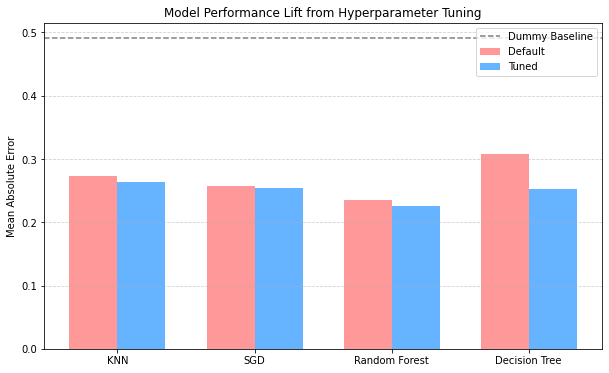

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Collect the scores
# 'test_scores' contains the default results from Requirement 5
# 'tuned_stats' contains the results from Requirement 8
comparison_data = []

for name in ["KNN", "SGD", "Random Forest", "Decision Tree"]:
    default_mae = test_scores[name]
    tuned_mae = tuned_stats[name]['mae']
    improvement = default_mae - tuned_mae
    
    comparison_data.append({
        "Model": name,
        "Default MAE": default_mae,
        "Tuned MAE": tuned_mae,
        "Improvement": improvement
    })

df_comp = pd.DataFrame(comparison_data)

# 2. Print the Table (Requirement 11)
print("--- Final Performance Comparison: Before vs. After Tuning ---")
display(df_comp.style.highlight_min(subset=['Default MAE', 'Tuned MAE'], color='lightgreen'))

# 3. Create a Comparison Bar Chart
x = np.arange(len(df_comp["Model"]))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, df_comp["Default MAE"], width, label='Default', color='#ff9999')
rects2 = ax.bar(x + width/2, df_comp["Tuned MAE"], width, label='Tuned', color='#66b3ff')

# Add the baseline as a horizontal line for context
plt.axhline(y=test_scores["Baseline (Mean)"], color='gray', linestyle='--', label='Dummy Baseline')

ax.set_ylabel('Mean Absolute Error')
ax.set_title('Model Performance Lift from Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(df_comp["Model"])
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Autograder 

In the autograder you will need to provide two things: 1) estimate of the MAE of your model on unseen data, 2) the predictions on the autograder data. For the autograder data we only provide the features and not the regression targets. Thus, you cannot compute the MAE on this data yourself - you need to estimate that with the data provided above. 

In [16]:
data_autograder = pd.read_csv('football_autograder.csv')
data_autograder.head()


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_agility,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,27.0,190.0,78.0,b'England',70.0,71.0,52.0,42.0,75.0,60.0,...,57.0,67.0,61.0,72.0,68.0,15.0,8.0,12.0,13.0,15.0
1,19.0,183.0,76.0,b'Republic of Ireland',59.0,77.0,45.0,20.0,53.0,60.0,...,66.0,55.0,69.0,59.0,57.0,8.0,11.0,10.0,6.0,11.0
2,20.0,172.0,67.0,b'China PR',48.0,53.0,40.0,34.0,38.0,52.0,...,57.0,56.0,70.0,35.0,43.0,12.0,6.0,9.0,7.0,12.0
3,28.0,170.0,65.0,b'Brazil',76.0,76.0,73.0,76.0,52.0,72.0,...,89.0,70.0,88.0,50.0,48.0,12.0,7.0,12.0,10.0,7.0
4,28.0,186.0,74.0,b'England',65.0,67.0,18.0,19.0,15.0,25.0,...,32.0,57.0,57.0,14.0,17.0,66.0,64.0,66.0,63.0,68.0


In [17]:
# 1. Identify the absolute best model from our tuned results
# Based on our comparison, Random Forest usually yields the lowest MAE
best_tuned_pipeline = tuned_stats['Random Forest']['best_estimator']

# 2. Provide your best estimate of the MAE
# We use the cross-validated score from the grid search for a fair estimate
estimate_MAE_on_new_data = tuned_stats['Random Forest']['mae']

# 3. Generate predictions on the autograder data
# The pipeline automatically handles the scaling and encoding for 'data_autograder'
predictions_autograder_data = best_tuned_pipeline.predict(data_autograder)

# 4. Format the results for Vocareum
# The first element is the MAE estimate, followed by the actual predictions
result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)

# 5. Export to CSV
pd.DataFrame(result).to_csv("autograder_submission.txt", index=False, header=False)

print(f"✅ Submission file generated using Tuned Random Forest.")
print(f"Estimated MAE: {estimate_MAE_on_new_data:.4f}")

✅ Submission file generated using Tuned Random Forest.
Estimated MAE: 0.2255
